# Is the data normal


In [1]:
import json
import os

from scipy.stats import normaltest

metrics_dir = "metrics"

# Collect all Dice coefficients
metrics = [
    "dice_similarity_coefficient",
    "hausdorff_distance_95",
    "center_distance",
]
for metric in metrics:
    metrics = []
    for fname in os.listdir(metrics_dir):
        if fname.endswith(".json"):
            fpath = os.path.join(metrics_dir, fname)
            with open(fpath, "r") as f:
                data = json.load(f)
                metrics.extend([r[metric] for r in data["results"]])

    # Test for normality
    stat, p_value = normaltest(metrics)
    print(f"Normality test statistic: {stat:.4f}, p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"The {metric} scores are NOT normally distributed (reject H0).")
    else:
        print(
            f"The {metric} scores are likely normally distributed (fail to reject H0)."
        )
    print()

Normality test statistic: 1242.1707, p-value: 0.0000
The dice_similarity_coefficient scores are NOT normally distributed (reject H0).

Normality test statistic: 2703.8396, p-value: 0.0000
The hausdorff_distance_95 scores are NOT normally distributed (reject H0).

Normality test statistic: 2772.1000, p-value: 0.0000
The center_distance scores are NOT normally distributed (reject H0).



In [2]:
import pandas as pd

data_descriptions = [
    ("02_28_b+_bouncing_target_labeled.yaml.json", "SAM2.1 Base+", "Semi-auto"),
    (
        "02_28_b+_trackrad_bouncing_target_combined.yaml.json",
        "SAM2.1 Base+",
        "Combined",
    ),
    ("02_28_b+_trackrad_labeled_training.yaml.json", "SAM2.1 Base+", "Manual"),
    ("02_28_l_bouncing_target_labeled.yaml.json", "SAM2.1 Large", "Semi-auto"),
    ("02_28_l_trackrad_bouncing_target_combined.yaml.json", "SAM2.1 Large", "Combined"),
    ("02_28_l_trackrad_labeled_training.yaml.json", "SAM2.1 Large", "Manual"),
    ("02_28_medsam2_bouncing_target_labeled.json", "MedSAM2", "Semi-auto"),
    ("02_28_medsam2_trackrad_bouncing_target_combined.json", "MedSAM2", "Combined"),
    ("02_28_medsam2_trackrad_labeled.json", "MedSAM2", "Manual"),
    ("02_28_s_bouncing_target_labeled.yaml.json", "SAM2.1 Small", "Semi-auto"),
    ("02_28_s_trackrad_bouncing_target_combined.yaml.json", "SAM2.1 Small", "Combined"),
    ("02_28_s_trackrad_labeled_training.yaml.json", "SAM2.1 Small", "Manual"),
    ("02_28_t_bouncing_target_labeled.yaml.json", "SAM2.1 Tiny", "Semi-auto"),
    ("02_28_t_trackrad_bouncing_target_combined.yaml.json", "SAM2.1 Tiny", "Combined"),
    ("02_28_t_trackrad_labeled_training.yaml.json", "SAM2.1 Tiny", "Manual"),
    ("base_plus.json", "SAM2.1 Base+", "Zero-shot"),
    ("large.json", "SAM2.1 Large", "Zero-shot"),
    ("medsam2_latest.json", "MedSAM2", "Zero-shot"),
    ("small.json", "SAM2.1 Small", "Zero-shot"),
    ("tiny.json", "SAM2.1 Tiny", "Zero-shot"),
]

df = pd.DataFrame()
for fname, base_model, fine_tune in data_descriptions:
    fpath = os.path.join(metrics_dir, fname)
    with open(fpath, "r") as f:
        data = json.load(f)
        dice_scores = [r["dice_similarity_coefficient"] for r in data["results"]]
        hausdorff_scores = [r["hausdorff_distance_95"] for r in data["results"]]
        center_distances = [r["center_distance"] for r in data["results"]]

    df = pd.concat(
        [
            df,
            pd.DataFrame(
                {
                    "Model": [base_model] * len(dice_scores),
                    "Fine-tuning Method": [fine_tune] * len(dice_scores),
                    "Dice coefficient": dice_scores,
                    "Hausdorff distance p95": hausdorff_scores,
                    "Centroid distance": center_distances,
                    "Time per frame (s)": [data["aggregates"]["time_per_frame"]]
                    * len(dice_scores),
                }
            ),
        ],
        ignore_index=True,
    )

df["Dice coefficient"] = pd.to_numeric(df["Dice coefficient"])
df["Hausdorff distance p95"] = pd.to_numeric(df["Hausdorff distance p95"])
df["Centroid distance"] = pd.to_numeric(df["Centroid distance"])
df["Time per frame (s)"] = pd.to_numeric(df["Time per frame (s)"])

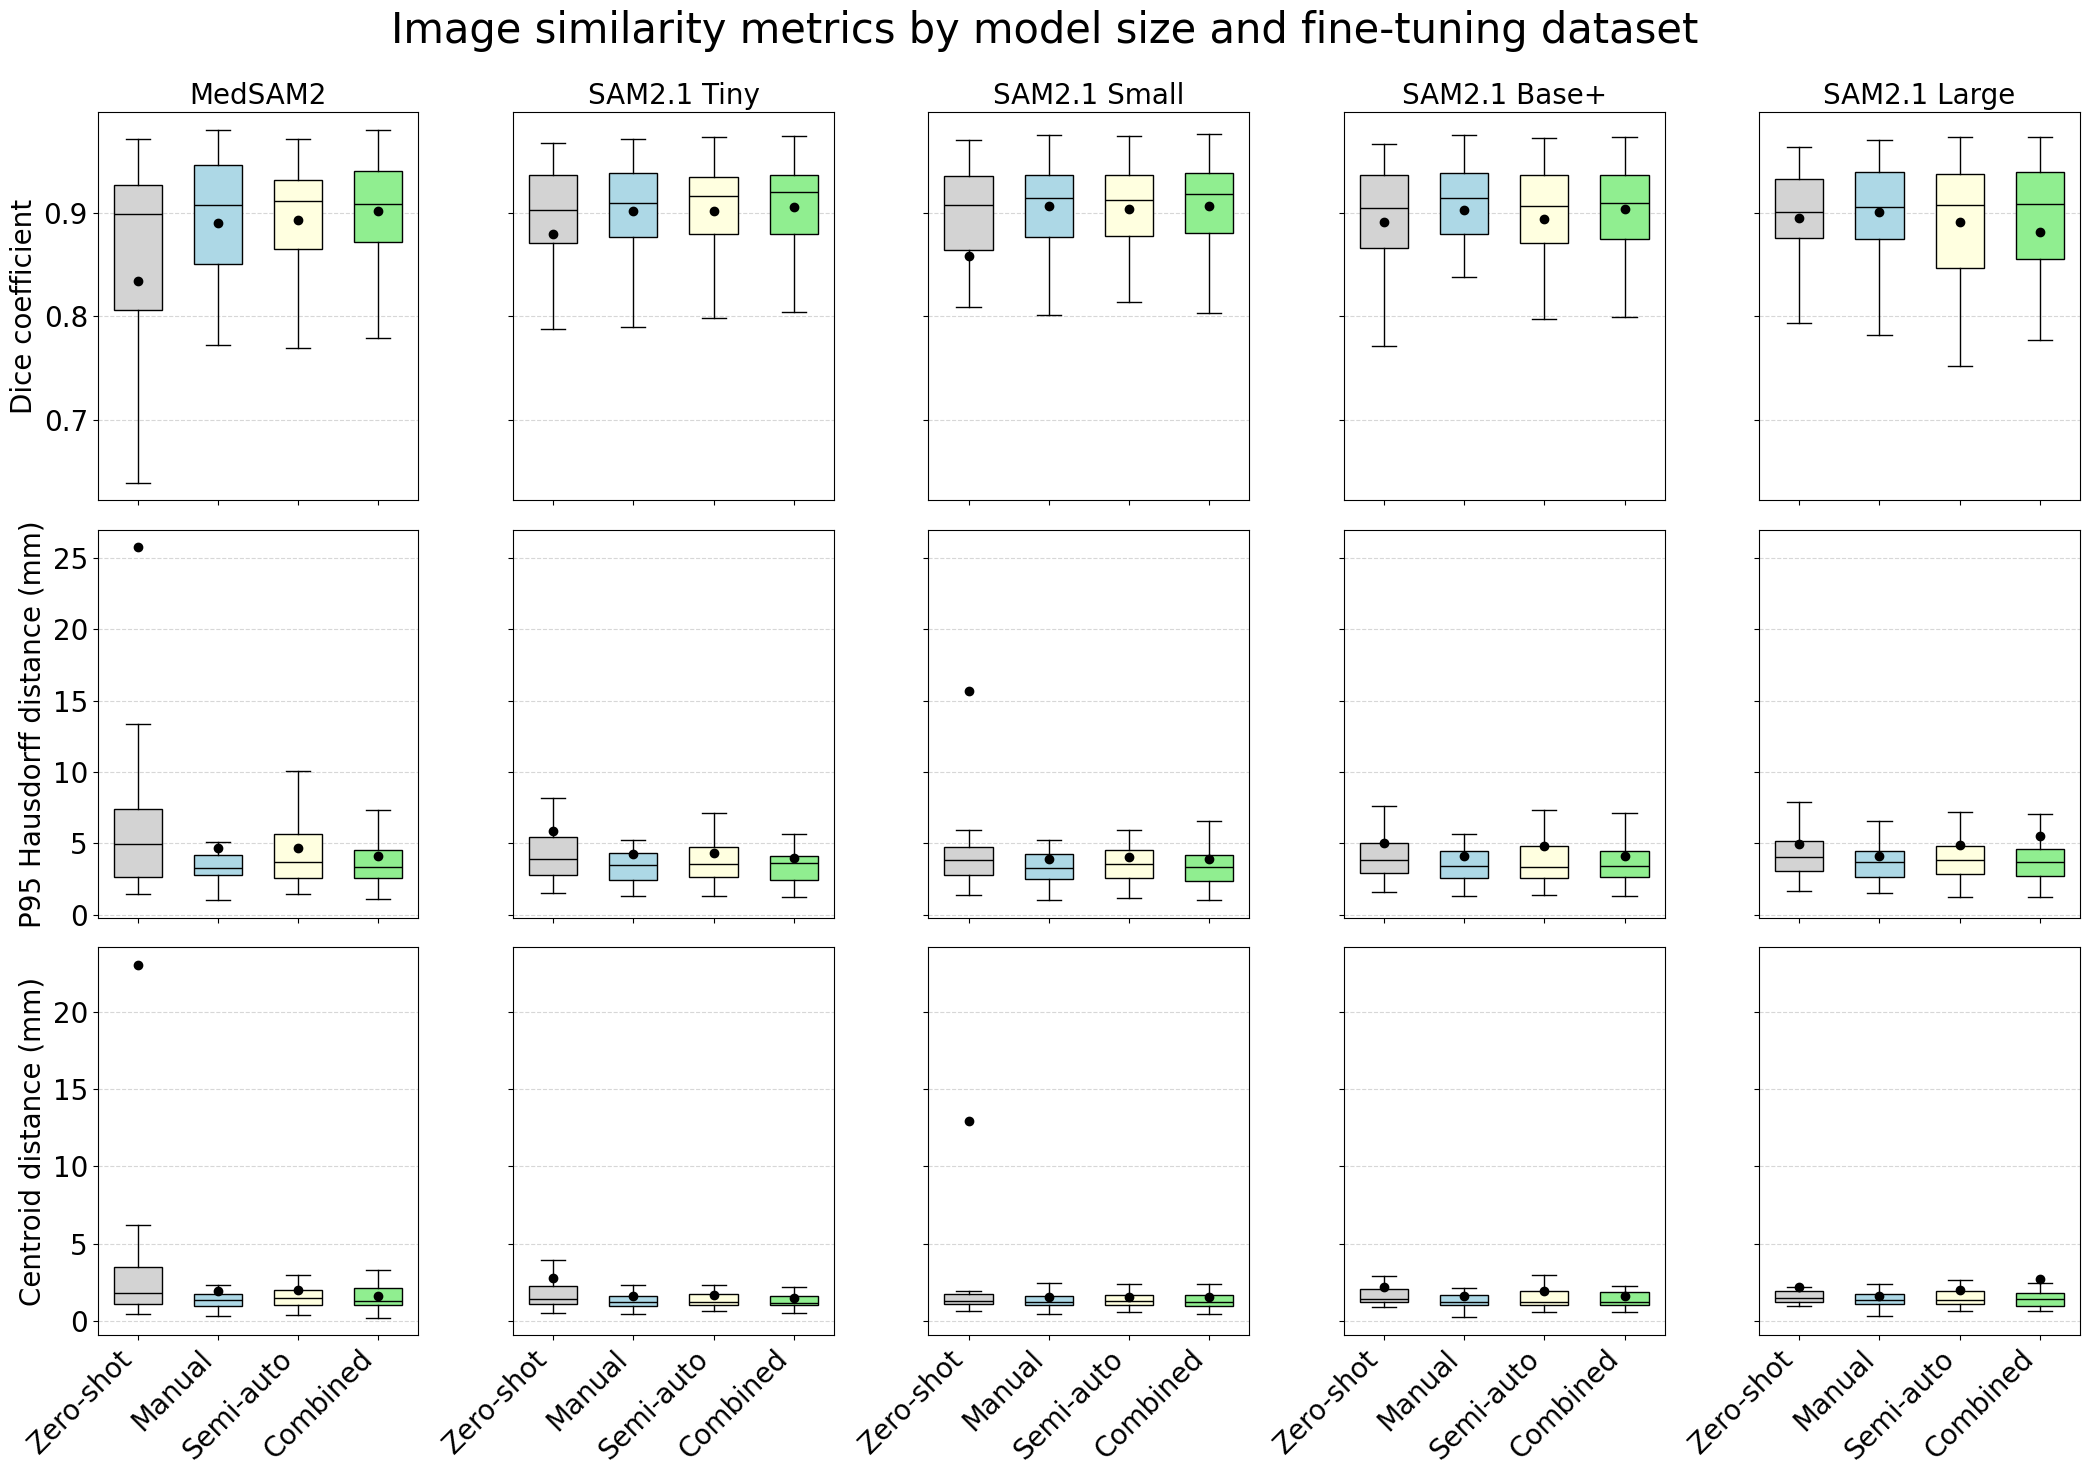

In [3]:
import numpy as np

import matplotlib.pyplot as plt

# Define desired order for models and fine-tuning methods
model_order = ["MedSAM2", "SAM2.1 Tiny", "SAM2.1 Small", "SAM2.1 Base+", "SAM2.1 Large"]
method_order = ["Zero-shot", "Manual", "Semi-auto", "Combined"]

ordered_index = [(model, method) for model in model_order for method in method_order]

metrics = [
    "Dice coefficient",
    "Hausdorff distance p95",
    "Centroid distance",
]

# Prepare data for plotting

bar_colors = [
    {
        "Zero-shot": "lightgray",
        "Manual": "lightblue",
        "Semi-auto": "lightyellow",
        "Combined": "lightgreen",
    }[method]
    for (model, method) in ordered_index
]

fig, axes = plt.subplots(
    len(metrics),
    len(model_order),
    figsize=(21, 5 * len(metrics)),
    sharex=True,
    sharey="row",
)

for m_idx, metric in enumerate(metrics):
    grouped = df.groupby(["Model", "Fine-tuning Method"])[metric]
    # Reindex by model and method order
    medians = grouped.median().reindex(ordered_index)
    q1 = grouped.quantile(0.25).reindex(ordered_index)
    q3 = grouped.quantile(0.75).reindex(ordered_index)
    means = grouped.mean().reindex(ordered_index)

    for i, model in enumerate(model_order):
        ax = axes[m_idx, i] if len(metrics) > 1 else axes[i]
        # Indices for this model in ordered_index
        idxs = [j for j, (m, _) in enumerate(ordered_index) if m == model]
        # Bar positions for this model
        x_model = np.arange(len(method_order))
        # Get stats for this model
        med = medians.loc[model].values
        m_q1 = q1.loc[model].values
        m_q3 = q3.loc[model].values
        m_mean = means.loc[model].values
        # Bar colors for this model
        colors = bar_colors[idxs[0] : idxs[0] + len(method_order)]
        # Plot boxplot without individual datapoints
        # Prepare data for boxplot: list of arrays, one per method
        data = [
            df[(df["Model"] == model) & (df["Fine-tuning Method"] == method)][
                metric
            ].values
            for method in method_order
        ]
        bp = ax.boxplot(
            data,
            positions=x_model,
            patch_artist=True,
            widths=0.6,
            boxprops=dict(facecolor="white", color="k"),
            medianprops=dict(color="k"),
            whiskerprops=dict(color="k"),
            capprops=dict(color="k"),
            showfliers=False,
        )
        # Set box colors
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
        ax.scatter(
            x_model,
            m_mean,
            color="black",
            marker="o",
            zorder=3,
            label="Mean" if m_idx == 0 and i == 0 else "",
        )
        if m_idx == 0:
            ax.set_title(model)

        ax.set_xticks(x_model)
        if m_idx == len(metrics) - 1:
            ax.set_xticklabels(method_order)
        else:
            ax.set_xticklabels([])
        if i == 0:
            if m_idx == 0:
                ax.set_ylabel("Dice coefficient")
            elif m_idx == 1:
                ax.set_ylabel("P95 Hausdorff distance (mm)")
            elif m_idx == 2:
                ax.set_ylabel("Centroid distance (mm)")

        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        ax.title.set_fontsize(20)
        ax.yaxis.label.set_fontsize(20)
        ax.tick_params(axis="x", labelsize=20)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        ax.tick_params(axis="y", labelsize=20)

plt.suptitle(
    "Image similarity metrics by model size and fine-tuning dataset", fontsize=30
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
fig.savefig("figures/image_similarity_metrics.pdf", format="pdf", bbox_inches="tight")

In [13]:
# Create a summary table of median Hausdorff distances for Zero-shot models
zero_shot_hausdorff = (
    df[df["Fine-tuning Method"] == "Zero-shot"]
    .groupby("Model")["Hausdorff distance p95"]
    .median()
    .sort_values()
)
print("Median P95 Hausdorff Distance (Zero-shot models):")
print(zero_shot_hausdorff)

Median P95 Hausdorff Distance (Zero-shot models):
Model
SAM2.1 Small    3.807071
SAM2.1 Base+    3.833285
SAM2.1 Tiny     3.895391
SAM2.1 Large    4.063279
MedSAM2         4.927782
Name: Hausdorff distance p95, dtype: float64


In [16]:
# Create a summary table of median Hausdorff distances for Zero-shot models
zero_shot_centroid = (
    df[df["Fine-tuning Method"] == "Zero-shot"]
    .groupby("Model")["Centroid distance"]
    .median()
    .sort_values()
)
print("Median P95 Hausdorff Distance (Zero-shot models):")
print(zero_shot_centroid)

Median P95 Hausdorff Distance (Zero-shot models):
Model
SAM2.1 Small    1.308118
SAM2.1 Tiny     1.429216
SAM2.1 Base+    1.441228
SAM2.1 Large    1.482231
MedSAM2         1.832595
Name: Centroid distance, dtype: float64


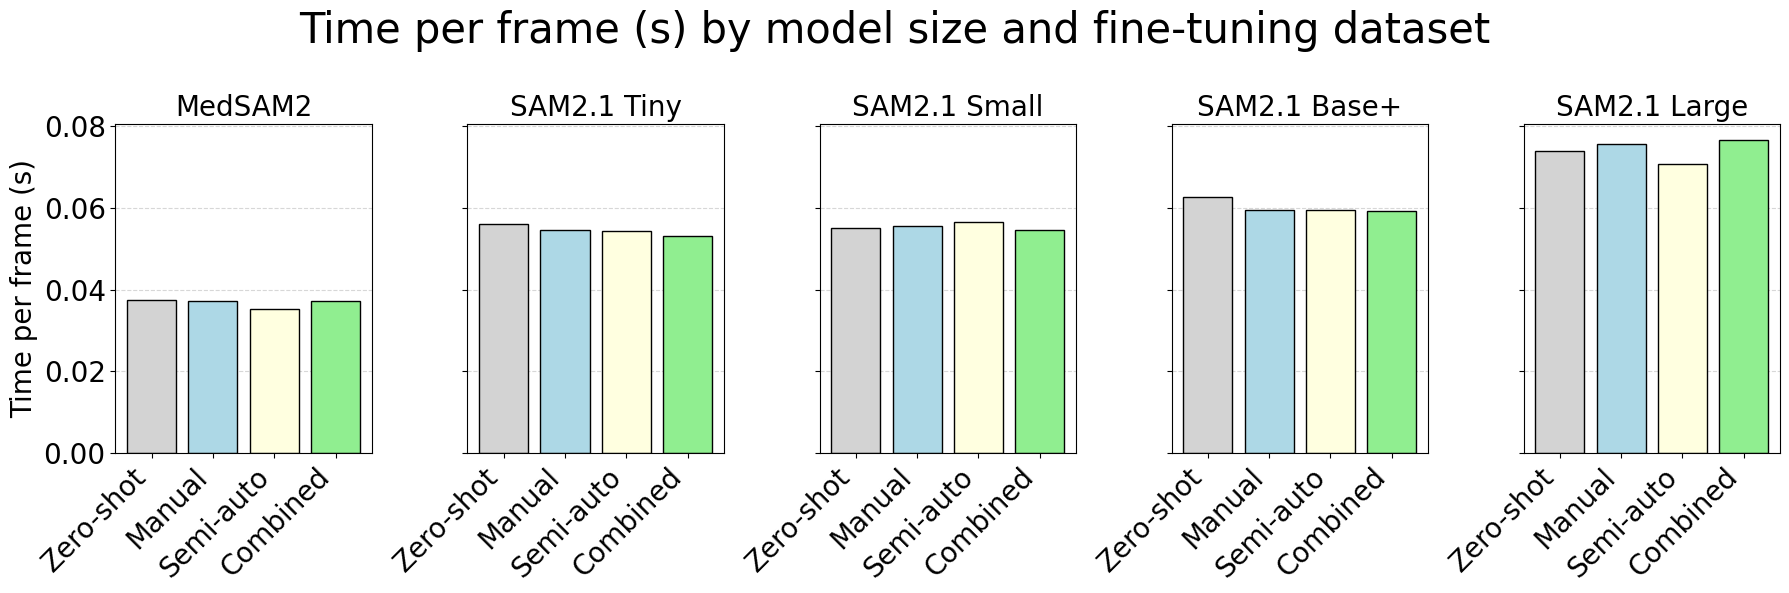

In [4]:
import numpy as np

import matplotlib.pyplot as plt

# Define desired order for models and fine-tuning methods
model_order = ["MedSAM2", "SAM2.1 Tiny", "SAM2.1 Small", "SAM2.1 Base+", "SAM2.1 Large"]
method_order = ["Zero-shot", "Manual", "Semi-auto", "Combined"]

ordered_index = [(model, method) for model in model_order for method in method_order]

metrics = [
    # "Dice coefficient",
    # "Hausdorff distance p95",
    # "Centroid distance",
    "Time per frame (s)",
]

# Prepare data for plotting

bar_colors = [
    {
        "Zero-shot": "lightgray",
        "Manual": "lightblue",
        "Semi-auto": "lightyellow",
        "Combined": "lightgreen",
    }[method]
    for (model, method) in ordered_index
]

for metric in metrics:
    grouped = df.groupby(["Model", "Fine-tuning Method"])[metric]
    # Reindex by model and method order
    medians = grouped.median().reindex(ordered_index)
    q1 = grouped.quantile(0.25).reindex(ordered_index)
    q3 = grouped.quantile(0.75).reindex(ordered_index)
    means = grouped.mean().reindex(ordered_index)

    fig, axes = plt.subplots(1, len(model_order), figsize=(18, 6), sharey=True)
    for i, model in enumerate(model_order):
        ax = axes[i]
        # Indices for this model in ordered_index
        idxs = [j for j, (m, _) in enumerate(ordered_index) if m == model]
        # Bar positions for this model
        x_model = np.arange(len(method_order))
        # Get stats for this model
        med = medians.loc[model].values
        m_q1 = q1.loc[model].values
        m_q3 = q3.loc[model].values
        m_mean = means.loc[model].values
        # Bar colors for this model
        colors = bar_colors[idxs[0] : idxs[0] + len(method_order)]
        # Plot bars
        ax.bar(
            x_model,
            med,
            capsize=5,
            color=colors,
            edgecolor="k",
            zorder=2,
        )
        ax.set_xticks(x_model)
        ax.set_xticklabels(method_order)
        ax.set_title(model)
        if metric == "Dice coefficient":
            ax.set_ylim([0.8, 1.0])
        if i == 0:
            ax.set_ylabel(metric)
        ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=1)

        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        ax.title.set_fontsize(20)
        ax.yaxis.label.set_fontsize(20)
        ax.tick_params(axis="x", labelsize=20)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        ax.tick_params(axis="y", labelsize=20)

    plt.suptitle(f"{metric} by model size and fine-tuning dataset", fontsize=30)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    fig.savefig("figures/runtime.pdf", format="pdf", bbox_inches="tight")

In [5]:
from scipy.stats import kruskal
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

metrics = [
    "Dice coefficient",
    "Hausdorff distance p95",
    "Centroid distance",
]

# Kruskal-Wallis test across all Zero-shot models for each metric
kw_zeroshot_results = []
for metric in metrics:
    # Collect Zero-shot scores for each model
    groups = [
        df[(df["Model"] == model) & (df["Fine-tuning Method"] == "Zero-shot")][
            metric
        ].astype(float)
        for model in model_order
    ]
    stat, p = kruskal(*groups)
    kw_zeroshot_results.append({"Metric": metric, "H-statistic": stat, "p-value": p})
kw_zeroshot_df = pd.DataFrame(kw_zeroshot_results)
print("Kruskal-Wallis test across Zero-shot models:")
print(kw_zeroshot_df)

# Pairwise Wilcoxon tests between Zero-shot models for each metric
wilcoxon_zeroshot_results = []
for metric in metrics:
    # Get Zero-shot scores for each model
    model_scores = {
        model: df[(df["Model"] == model) & (df["Fine-tuning Method"] == "Zero-shot")][
            metric
        ]
        .astype(float)
        .values
        for model in model_order
    }
    pairs = []
    pvals = []
    for i in range(len(model_order)):
        for j in range(i + 1, len(model_order)):
            m1, m2 = model_order[i], model_order[j]
            s1, s2 = model_scores[m1], model_scores[m2]
            # Only test if same length and more than 0 samples
            if len(s1) == len(s2) and len(s1) > 0:
                try:
                    stat, p = wilcoxon(s1, s2)
                    pairs.append((m1, m2, stat))
                    pvals.append(p)
                except Exception:
                    pairs.append((m1, m2, None))
                    pvals.append(None)
            else:
                pairs.append((m1, m2, None))
                pvals.append(None)
    # Multiple comparisons correction (Holm)
    valid_pvals = [p for p in pvals if p is not None]
    if valid_pvals:
        reject, pvals_corr, _, _ = multipletests(valid_pvals, method="holm")
    else:
        pvals_corr = []
    corr_idx = 0
    for idx, (m1, m2, stat) in enumerate(pairs):
        orig_p = pvals[idx]
        corr_p = pvals_corr[corr_idx] if orig_p is not None else None
        if orig_p is not None:
            corr_idx += 1
        wilcoxon_zeroshot_results.append(
            {
                "Metric": metric,
                "Model 1": m1,
                "Model 2": m2,
                "W-statistic": stat,
                "p-value": orig_p,
                "p-value Holm": corr_p,
            }
        )
wilcoxon_zeroshot_df = pd.DataFrame(wilcoxon_zeroshot_results)
print("\nWilcoxon pairwise tests between Zero-shot models (Holm-corrected):")
print(wilcoxon_zeroshot_df)

Kruskal-Wallis test across Zero-shot models:
                   Metric  H-statistic   p-value
0        Dice coefficient     2.090598  0.719100
1  Hausdorff distance p95     2.595426  0.627634
2       Centroid distance     3.267868  0.514039

Wilcoxon pairwise tests between Zero-shot models (Holm-corrected):
                    Metric       Model 1       Model 2  W-statistic   p-value  \
0         Dice coefficient       MedSAM2   SAM2.1 Tiny        262.0  0.118111   
1         Dice coefficient       MedSAM2  SAM2.1 Small        290.0  0.249111   
2         Dice coefficient       MedSAM2  SAM2.1 Base+        287.0  0.231613   
3         Dice coefficient       MedSAM2  SAM2.1 Large        209.0  0.018315   
4         Dice coefficient   SAM2.1 Tiny  SAM2.1 Small        347.0  0.741572   
5         Dice coefficient   SAM2.1 Tiny  SAM2.1 Base+        354.0  0.818591   
6         Dice coefficient   SAM2.1 Tiny  SAM2.1 Large        327.0  0.537113   
7         Dice coefficient  SAM2.1 Small  S

In [6]:
from scipy.stats import kruskal

# Prepare groups for each of the 20 (model, fine-tuning) combinations
kw_results_20 = []
for metric in metrics:
    groups = [
        df[(df["Model"] == model) & (df["Fine-tuning Method"] == method)][
            metric
        ].astype(float)
        for model, method in ordered_index
    ]
    # Only include groups with at least one value
    valid_groups = [g for g in groups if len(g) > 0]
    stat, p = kruskal(*valid_groups)
    kw_results_20.append({"Metric": metric, "H-statistic": stat, "p-value": p})

pd.DataFrame(kw_results_20)

,Metric,H-statistic,p-value
0,Dice coefficient,9.144767,0.970997
1,Hausdorff distance p95,20.337989,0.374504
2,Centroid distance,25.461524,0.145905


In [7]:
# Prepare results list
kruskal_results_list = []

for metric in metrics:
    for model in model_order:
        # Collect metric scores for each fine-tuning method within this model
        groups = [
            df[(df["Model"] == model) & (df["Fine-tuning Method"] == method)][
                metric
            ].astype(float)
            for method in method_order
        ]
        if len(groups) > 1:
            stat, p = kruskal(*groups)
            kruskal_results_list.append(
                {"Metric": metric, "Model": model, "H-statistic": stat, "p-value": p}
            )
        else:
            kruskal_results_list.append(
                {"Metric": metric, "Model": model, "H-statistic": None, "p-value": None}
            )

kruskal_df = pd.DataFrame(kruskal_results_list)
kruskal_df

,Metric,Model,H-statistic,p-value
0,Dice coefficient,MedSAM2,3.421243,0.331121
1,Dice coefficient,SAM2.1 Tiny,0.959345,0.811088
2,Dice coefficient,SAM2.1 Small,1.199690,0.753079
3,Dice coefficient,SAM2.1 Base+,0.802156,0.848951
4,Dice coefficient,SAM2.1 Large,0.218755,0.974506
5,Hausdorff distance p95,MedSAM2,5.447314,0.141824
6,Hausdorff distance p95,SAM2.1 Tiny,3.093558,0.377424
7,Hausdorff distance p95,SAM2.1 Small,2.454294,0.483608
8,Hausdorff distance p95,SAM2.1 Base+,2.872766,0.411661
9,Hausdorff distance p95,SAM2.1 Large,1.773016,0.620824


In [8]:
# Prepare results list
wilcoxon_results_list = []

for metric in metrics:
    for model in model_order:
        # Get all methods for this model
        method_scores = {
            method: df[(df["Model"] == model) & (df["Fine-tuning Method"] == method)][
                metric
            ]
            .astype(float)
            .values
            for method in method_order
        }
        # Pairwise comparisons
        pairs = []
        pvals = []
        for i in range(len(method_order)):
            for j in range(i + 1, len(method_order)):
                m1, m2 = method_order[i], method_order[j]
                scores1, scores2 = method_scores[m1], method_scores[m2]
                # Only test if same length and more than 0 samples
                if len(scores1) == len(scores2) and len(scores1) > 0:
                    try:
                        stat, p = wilcoxon(scores1, scores2)
                        pairs.append((m1, m2, stat))
                        pvals.append(p)
                    except Exception as e:
                        pairs.append((m1, m2, None))
                        pvals.append(None)
                else:
                    pairs.append((m1, m2, None))
                    pvals.append(None)
        # Holm correction
        valid_pvals = [p for p in pvals if p is not None]
        if valid_pvals:
            reject, pvals_corr, _, _ = multipletests(valid_pvals, method="holm")
        else:
            pvals_corr = []
        # Fill results
        corr_idx = 0
        for idx, (m1, m2, stat) in enumerate(pairs):
            orig_p = pvals[idx]
            corr_p = pvals_corr[corr_idx] if orig_p is not None else None
            if orig_p is not None:
                corr_idx += 1
            wilcoxon_results_list.append(
                {
                    "Metric": metric,
                    "Model": model,
                    "Method 1": m1,
                    "Method 2": m2,
                    "W-statistic": stat,
                    "p-value": orig_p,
                    "p-value Holm": corr_p,
                }
            )

wilcoxon_df_holm = pd.DataFrame(wilcoxon_results_list)
wilcoxon_df_holm

,Metric,Model,Method 1,Method 2,W-statistic,p-value,p-value Holm
0,Dice coefficient,MedSAM2,Zero-shot,Manual,264.0,0.125213,0.500853
1,Dice coefficient,MedSAM2,Zero-shot,Semi-auto,236.0,0.051233,0.256165
2,Dice coefficient,MedSAM2,Zero-shot,Combined,225.0,0.034404,0.206423
3,Dice coefficient,MedSAM2,Manual,Semi-auto,359.0,0.874720,1.000000
4,Dice coefficient,MedSAM2,Manual,Combined,338.0,0.646237,1.000000
...,...,...,...,...,...,...,...
85,Centroid distance,SAM2.1 Large,Zero-shot,Semi-auto,348.0,0.752440,1.000000
86,Centroid distance,SAM2.1 Large,Zero-shot,Combined,311.0,0.396465,1.000000
87,Centroid distance,SAM2.1 Large,Manual,Semi-auto,334.0,0.605517,1.000000
88,Centroid distance,SAM2.1 Large,Manual,Combined,348.0,0.752440,1.000000


# 2. Does fine-tuning improve performance?


In [9]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# Prepare the DataFrame for GLM
metrics = [
    "Dice coefficient",
    "Hausdorff distance p95",
    "Centroid distance",
]

glm_metrics = ["dice", "hausdorff", "center", "time_per_frame"]
image_metrics = ["dice", "hausdorff", "center"]

glm_df = df.rename(
    columns={
        "Model": "model",
        "Fine-tuning Method": "tune",
        "Dice coefficient": "dice",
        "Hausdorff distance p95": "hausdorff",
        "Centroid distance": "center",
        "Time per frame (s)": "time_per_frame",
    }
).copy()
# Add a 'dataset' column based on the order in data_descriptions (repeat index for each sample)
dataset_names = [desc[0] for desc in data_descriptions]
samples_per_dataset = [
    len(df[(df["Model"] == desc[1]) & (df["Fine-tuning Method"] == desc[2])])
    for desc in data_descriptions
]
glm_df["dataset"] = sum(
    [[name] * n for name, n in zip(dataset_names, samples_per_dataset)], []
)
# Set model order as categorical
model_order_labels = [
    "MedSAM2",
    "SAM2.1 Tiny",
    "SAM2.1 Small",
    "SAM2.1 Base+",
    "SAM2.1 Large",
]
glm_df["model"] = pd.Categorical(
    glm_df["model"], categories=model_order_labels, ordered=True
)
glm_df["fine_tuned"] = ~glm_df["tune"].isin(["Zero-shot"])

# Fit a GLM for each metric and apply Holm correction to p-values
glm_results = {}
pvals = []
metric_names = []

for metric_col, metric_name in zip(glm_metrics, metrics):
    formula = f"{metric_col} ~ fine_tuned"
    model = smf.mixedlm(formula, glm_df, groups=glm_df["dataset"])
    result = model.fit()
    glm_results[metric_name] = result
    # Collect p-value for the 'tune' variable (excluding Intercept)
    # The first row is Intercept, the rest are levels of 'tune'
    # We take all except Intercept
    for param in result.pvalues.index:
        if param not in ["Intercept", "Group Var"]:
            pvals.append(result.pvalues[param])
            metric_names.append(f"{metric_name} ({param})")
    print(f"GLM for {metric_name}:\n", result.summary(), "\n")

# Apply Bonferroni correction
if pvals:
    reject, pvals_corr, _, _ = multipletests(pvals, method="bonferroni")
    print("Bonferroni-corrected p-values for 'tune' effects across metrics:")
    for name, orig_p, corr_p, rej in zip(metric_names, pvals, pvals_corr, reject):
        print(
            f"{name}: original p={orig_p:.4g}, Bonferroni-corrected p={corr_p:.4g}, reject H0: {rej}"
        )

GLM for Dice coefficient:
             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   dice    
No. Observations:    760       Method:               REML    
No. Groups:          20        Scale:                0.0069  
Min. group size:     38        Log-Likelihood:       804.8859
Max. group size:     38        Converged:            Yes     
Mean group size:     38.0                                    
-------------------------------------------------------------
                   Coef. Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          0.871    0.006 141.624 0.000  0.859  0.883
fine_tuned[T.True] 0.027    0.007   3.856 0.000  0.013  0.041
Group Var          0.000    0.001                            
 

GLM for Hausdorff distance p95:
             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   hausdorff 
No. Observations:   760       

/Users/zhu.henian/projects/trackrad2025/notebooks/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



Dice coefficient:
  Shapiro-Wilk: stat=0.9072, p-value=0.0000
  D'Agostino-Pearson: stat=98.9783, p-value=0.0000
  Residuals are NOT normally distributed (reject H0)

Hausdorff distance p95:
  Shapiro-Wilk: stat=0.6441, p-value=0.0000
  D'Agostino-Pearson: stat=265.7012, p-value=0.0000
  Residuals are NOT normally distributed (reject H0)

Centroid distance:
  Shapiro-Wilk: stat=0.6699, p-value=0.0000
  D'Agostino-Pearson: stat=228.3300, p-value=0.0000
  Residuals are NOT normally distributed (reject H0)


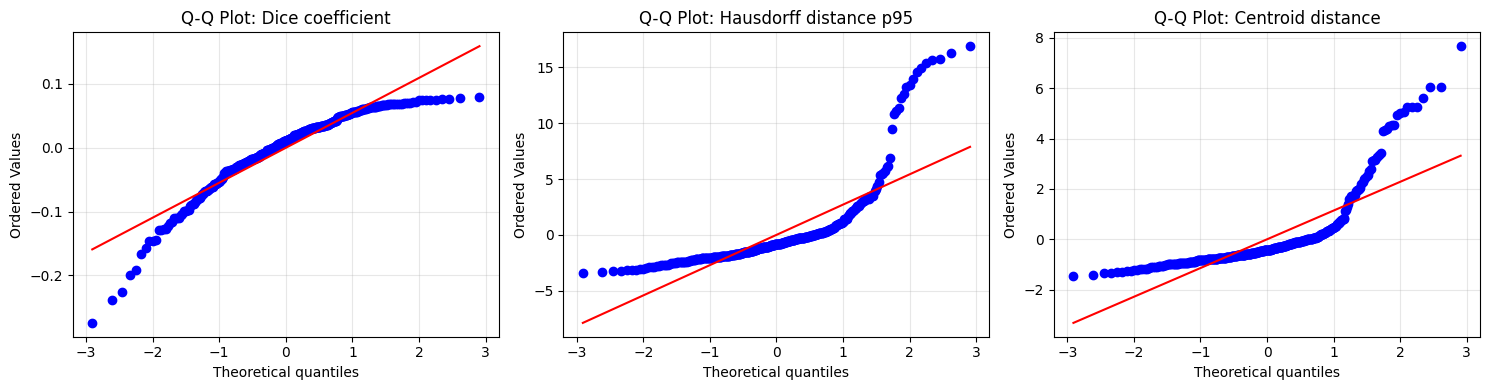

In [17]:
from scipy.stats import shapiro, normaltest
from scipy import stats

import matplotlib.pyplot as plt

# Extract residuals from the GLM results
residuals_by_metric = {}
for metric_name, result in glm_results.items():
    residuals = result.resid
    residuals_by_metric[metric_name] = residuals

    # Shapiro-Wilk test for normality
    stat_sw, p_sw = shapiro(residuals)

    # Anderson-Darling test (alternative)
    stat_ad, p_ad = normaltest(residuals)

    print(f"\n{metric_name}:")
    print(f"  Shapiro-Wilk: stat={stat_sw:.4f}, p-value={p_sw:.4f}")
    print(f"  D'Agostino-Pearson: stat={stat_ad:.4f}, p-value={p_ad:.4f}")
    if p_sw < 0.05:
        print(f"  Residuals are NOT normally distributed (reject H0)")
    else:
        print(f"  Residuals are likely normally distributed (fail to reject H0)")

# Q-Q plots to visualize normality
fig, axes = plt.subplots(1, len(glm_results), figsize=(15, 4))
for idx, (metric_name, residuals) in enumerate(residuals_by_metric.items()):
    ax = axes[idx] if len(glm_results) > 1 else axes
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {metric_name}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Is the manually-labeled dataset different from auto-labeled?


In [19]:
import statsmodels.formula.api as smf

# Prepare the DataFrame for GLM
glm_metrics = ["dice", "hausdorff", "center", "time_per_frame"]
glm_df = df.rename(
    columns={
        "Model": "model",
        "Fine-tuning Method": "tune",
        "Dice coefficient": "dice",
        "Hausdorff distance p95": "hausdorff",
        "Centroid distance": "center",
        "Time per frame (s)": "time_per_frame",
    }
).copy()
# Add a 'dataset' column based on the order in data_descriptions (repeat index for each sample)
dataset_names = [desc[0] for desc in data_descriptions]
samples_per_dataset = [
    len(df[(df["Model"] == desc[1]) & (df["Fine-tuning Method"] == desc[2])])
    for desc in data_descriptions
]
glm_df["dataset"] = sum(
    [[name] * n for name, n in zip(dataset_names, samples_per_dataset)], []
)
# Set model order as categorical
model_order_labels = [
    "MedSAM2",
    "SAM2.1 Tiny",
    "SAM2.1 Small",
    "SAM2.1 Base+",
    "SAM2.1 Large",
]
tuning_methods = ["Manual", "Semi-auto"]
glm_df["model"] = pd.Categorical(
    glm_df["model"], categories=model_order_labels, ordered=True
)
glm_df = glm_df[
    glm_df["tune"].isin(tuning_methods)
].copy()  # Filter to only Manual and Semi-auto
glm_df["tune"] = pd.Categorical(glm_df["tune"], categories=tuning_methods, ordered=True)

# Fit a GLM for each metric
glm_results = {}
pvals = []
for metric_col, metric_name in zip(glm_metrics, metrics):
    formula = f"{metric_col} ~ tune"
    model = smf.mixedlm(formula, glm_df, groups=glm_df["dataset"])
    result = model.fit()
    glm_results[metric_name] = result
    print(f"GLM for {metric_name}:\n", result.summary(), "\n")

    # Collect p-value for the 'tune' variable (excluding Intercept)
    # The first row is Intercept, the rest are levels of 'tune'
    # We take all except Intercept
    for param in result.pvalues.index:
        if param not in ["Intercept", "Group Var"]:
            pvals.append(result.pvalues[param])
            metric_names.append(f"{metric_name} ({param})")

# Apply Bonferroni correction
if pvals:
    reject, pvals_corr, _, _ = multipletests(pvals, method="bonferroni")
    print("Bonferroni-corrected p-values for 'tune' effects across metrics:")
    for name, orig_p, corr_p, rej in zip(metric_names, pvals, pvals_corr, reject):
        print(
            f"{name}: original p={orig_p:.4g}, Bonferroni-corrected p={corr_p:.4g}, reject H0: {rej}"
        )

GLM for Dice coefficient:
             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   dice    
No. Observations:    380       Method:               REML    
No. Groups:          10        Scale:                0.0033  
Min. group size:     38        Log-Likelihood:       539.2581
Max. group size:     38        Converged:            Yes     
Mean group size:     38.0                                    
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          0.900    0.004 216.601 0.000  0.892  0.909
tune[T.Semi-auto] -0.004    0.006  -0.665 0.506 -0.015  0.008
Group Var          0.000                                     
 

GLM for Hausdorff distance p95:
            Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  hausdorff 
No. Observations:  380      Method

/Users/zhu.henian/projects/trackrad2025/notebooks/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/zhu.henian/projects/trackrad2025/notebooks/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/zhu.henian/projects/trackrad2025/notebooks/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/zhu.henian/projects/trackrad2025/notebooks/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/zhu.henian/projects/trackrad2025/notebooks/.venv/


Dice coefficient:
  Shapiro-Wilk: stat=0.9072, p-value=0.0000
  D'Agostino-Pearson: stat=98.9783, p-value=0.0000
  Residuals are NOT normally distributed (reject H0)

Hausdorff distance p95:
  Shapiro-Wilk: stat=0.6441, p-value=0.0000
  D'Agostino-Pearson: stat=265.7012, p-value=0.0000
  Residuals are NOT normally distributed (reject H0)

Centroid distance:
  Shapiro-Wilk: stat=0.6699, p-value=0.0000
  D'Agostino-Pearson: stat=228.3300, p-value=0.0000
  Residuals are NOT normally distributed (reject H0)


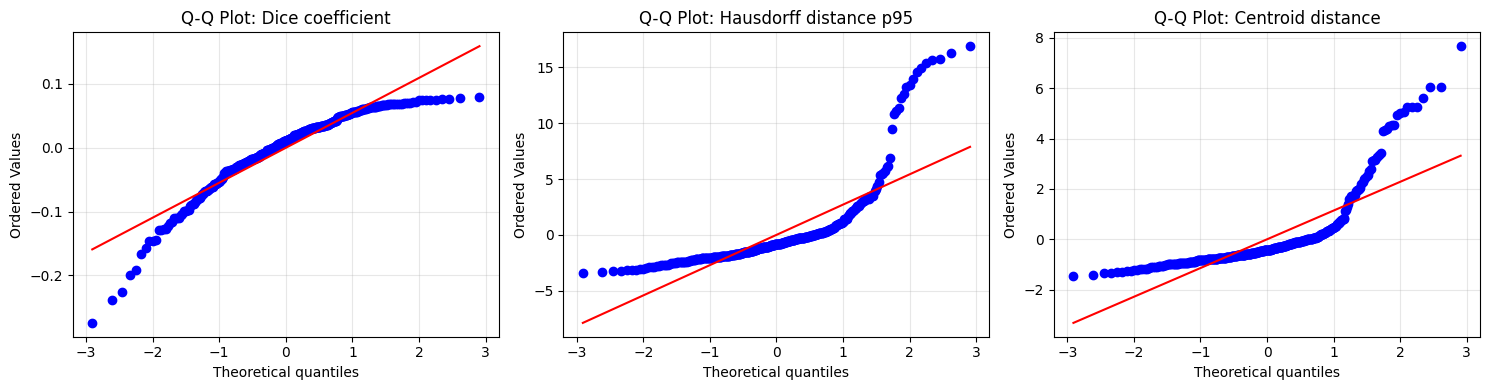

In [20]:
from scipy.stats import shapiro, normaltest
from scipy import stats

import matplotlib.pyplot as plt

# Extract residuals from the GLM results
residuals_by_metric = {}
for metric_name, result in glm_results.items():
    residuals = result.resid
    residuals_by_metric[metric_name] = residuals

    # Shapiro-Wilk test for normality
    stat_sw, p_sw = shapiro(residuals)

    # Anderson-Darling test (alternative)
    stat_ad, p_ad = normaltest(residuals)

    print(f"\n{metric_name}:")
    print(f"  Shapiro-Wilk: stat={stat_sw:.4f}, p-value={p_sw:.4f}")
    print(f"  D'Agostino-Pearson: stat={stat_ad:.4f}, p-value={p_ad:.4f}")
    if p_sw < 0.05:
        print(f"  Residuals are NOT normally distributed (reject H0)")
    else:
        print(f"  Residuals are likely normally distributed (fail to reject H0)")

# Q-Q plots to visualize normality
fig, axes = plt.subplots(1, len(glm_results), figsize=(15, 4))
for idx, (metric_name, residuals) in enumerate(residuals_by_metric.items()):
    ax = axes[idx] if len(glm_results) > 1 else axes
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {metric_name}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()